In [17]:
import pandas as pd

df = pd.read_excel("../data/Telco_customer_churn.xlsx")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [16]:
import os
print(os.listdir("../data"))


['Telco_customer_churn.xlsx']


In [18]:
df.shape

(7043, 33)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [21]:
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [22]:
df['Churn Label'].value_counts()


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

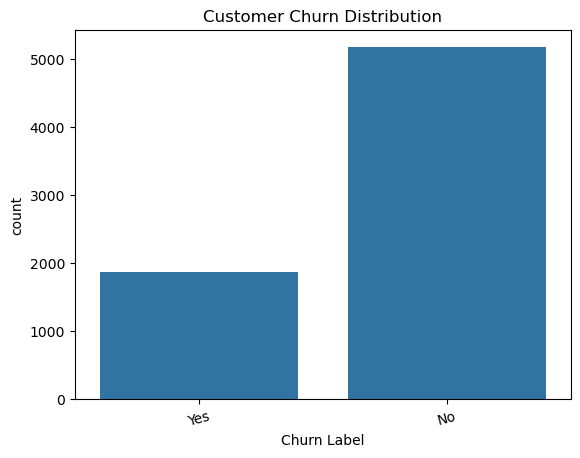

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn Label', data=df)
plt.title("Customer Churn Distribution")
plt.xticks(rotation=15)
plt.show()


In [24]:
df.isnull().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [25]:
df['Total Charges'].dtype


dtype('O')

In [26]:
# Check missing values
df.isnull().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [27]:
# Check Total Charges data type (usually problematic)
df['Total Charges'].dtype
df['Total Charges'].head()


0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
Name: Total Charges, dtype: object

In [28]:
# Convert Total Charges to numeric (remove spaces)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("After fix:")
print(df['Total Charges'].dtype)
print(df['Total Charges'].isnull().sum())


After fix:
float64
11


In [29]:
# Fill missing Total Charges with median (best practice)
median_charge = df['Total Charges'].median()
df['Total Charges'].fillna(median_charge, inplace=True)
print(f"Filled {df['Total Charges'].isnull().sum()} missing values with median: {median_charge}")


Filled 0 missing values with median: 1397.475


C:\Users\user\AppData\Local\Temp\ipykernel_7788\2027243381.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(median_charge, inplace=True)


In [30]:
print("Final missing values:")
print(df.isnull().sum().sum(), "total missing values left")
print("\nData types:")
print(df.dtypes)


Final missing values:
5174 total missing values left

Data types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn 

In [31]:
# Map Churn Label to 0/1
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
print("Churn distribution (0=No, 1=Yes):")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")


Churn distribution (0=No, 1=Yes):
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


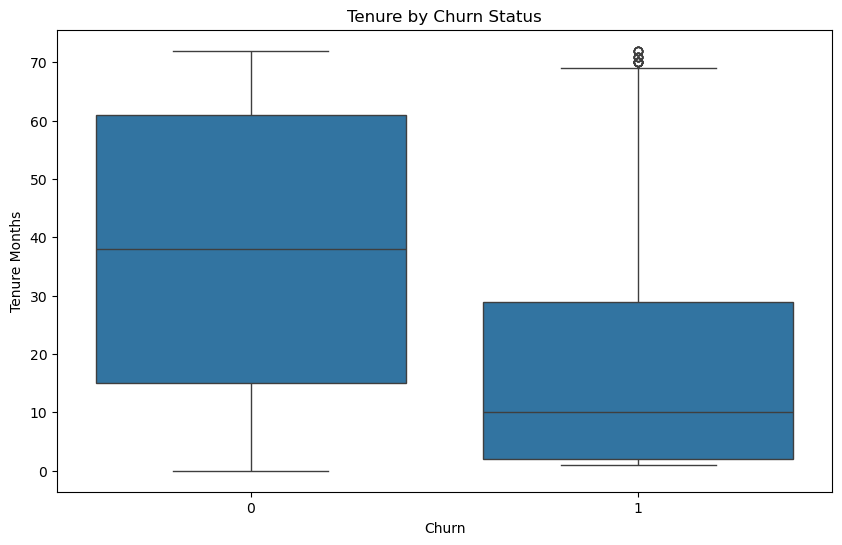

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='Tenure Months', data=df)
plt.title("Tenure by Churn Status")
plt.show()


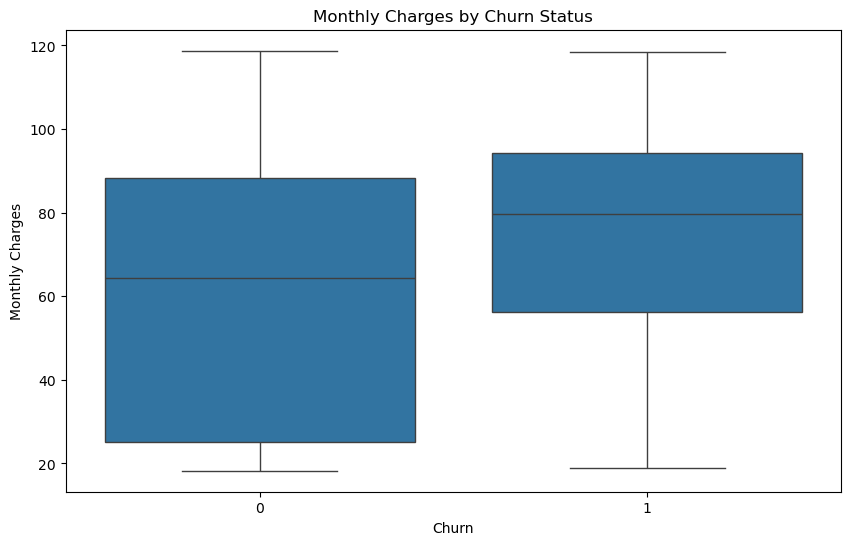

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='Monthly Charges', data=df)
plt.title("Monthly Charges by Churn Status")
plt.show()


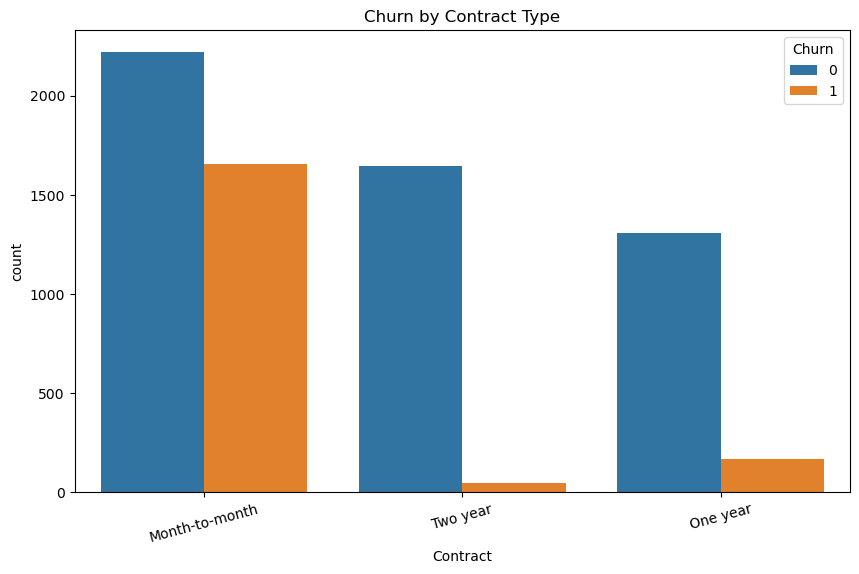

In [34]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()


In [35]:
# Save cleaned data for later notebooks
df.to_csv("../data/telco_cleaned.csv", index=False)
print("✅ Cleaned dataset saved as telco_cleaned.csv")


✅ Cleaned dataset saved as telco_cleaned.csv


In [36]:
# Sort by tenure (simulates time)
df_sorted = df.sort_values('Tenure Months').reset_index(drop=True)

# 70% train (early customers), 30% test (later customers)
split_idx = int(len(df_sorted) * 0.7)
train_df = df_sorted[:split_idx].copy()
test_df = df_sorted[split_idx:].copy()

print(f"Train: {len(train_df)} rows")
print(f"Test:  {len(test_df)} rows")
print(f"Test avg tenure: {test_df['Tenure Months'].mean():.1f} months")


Train: 4930 rows
Test:  2113 rows
Test avg tenure: 63.9 months


In [37]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Select key features only (simpler + faster)
features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Internet Service']
X_train = train_df[features].copy()
y_train = train_df['Churn']
X_test = test_df[features].copy()
y_test = test_df['Churn']

# Encode categorical columns
le = LabelEncoder()
X_train['Contract'] = le.fit_transform(X_train['Contract'])
X_test['Contract'] = le.transform(X_test['Contract'])
X_train['Internet Service'] = le.fit_transform(X_train['Internet Service'])
X_test['Internet Service'] = le.transform(X_test['Internet Service'])

print("Features ready:")
print(X_train.head())


Features ready:
   Tenure Months  Monthly Charges  Total Charges  Contract  Internet Service
0              0            19.70       1397.475         1                 2
1              0            52.55       1397.475         2                 0
2              0            25.35       1397.475         2                 2
3              0            80.85       1397.475         2                 0
4              0            19.85       1397.475         2                 2


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train baseline model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict on test set (later time period)
y_pred = model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Baseline Accuracy: 0.910

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1923
           1       0.00      0.00      0.00       190

    accuracy                           0.91      2113
   macro avg       0.46      0.50      0.48      2113
weighted avg       0.83      0.91      0.87      2113



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# CORRECT encoding - ONE encoder for both train/test
features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Internet Service']
X_train = train_df[features].copy()
y_train = train_df['Churn']
X_test = test_df[features].copy()
y_test = test_df['Churn']

# ONE encoder for Contract
le_contract = LabelEncoder()
X_train['Contract'] = le_contract.fit_transform(X_train['Contract'])
X_test['Contract'] = le_contract.transform(X_test['Contract'])  # Use SAME encoder

# ONE encoder for Internet Service  
le_internet = LabelEncoder()
X_train['Internet Service'] = le_internet.fit_transform(X_train['Internet Service'])
X_test['Internet Service'] = le_internet.transform(X_test['Internet Service'])  # Use SAME encoder

print("Fixed features ready:")
print(X_train.head())


Fixed features ready:
   Tenure Months  Monthly Charges  Total Charges  Contract  Internet Service
0              0            19.70       1397.475         1                 2
1              0            52.55       1397.475         2                 0
2              0            25.35       1397.475         2                 2
3              0            80.85       1397.475         2                 0
4              0            19.85       1397.475         2                 2


In [40]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest (much better for imbalanced data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.840

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1923
           1       0.13      0.14      0.14       190

    accuracy                           0.84      2113
   macro avg       0.52      0.53      0.52      2113
weighted avg       0.84      0.84      0.84      2113



In [41]:
from xgboost import XGBClassifier

# XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.894

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1923
           1       0.20      0.06      0.10       190

    accuracy                           0.89      2113
   macro avg       0.56      0.52      0.52      2113
weighted avg       0.85      0.89      0.87      2113



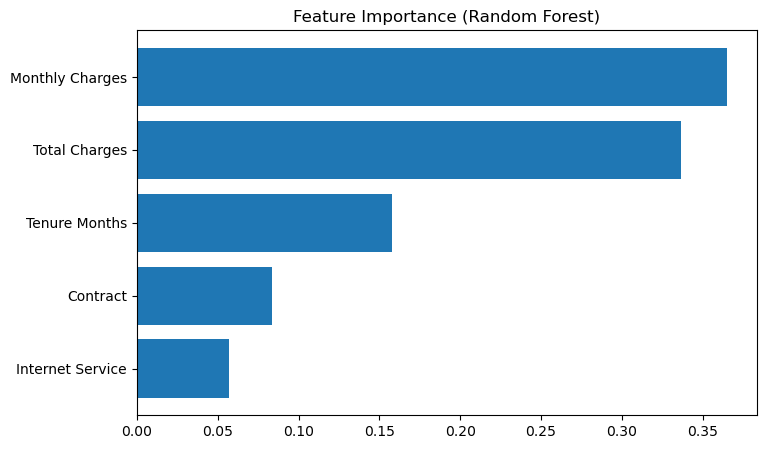

In [42]:
import matplotlib.pyplot as plt

# Plot feature importance from Random Forest
plt.figure(figsize=(8,5))
feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feat_importance['feature'], feat_importance['importance'])
plt.title("Feature Importance (Random Forest)")
plt.show()


In [43]:
# Simulate "future" data drift - Monthly Charges increase 20%
X_test_drift = X_test.copy()
X_test_drift['Monthly Charges'] *= 1.2  # Price hike
X_test_drift['Tenure Months'] *= 0.9    # Shorter tenure trend

print("Drift introduced:")
print("Original test avg Monthly Charges:", X_test['Monthly Charges'].mean())
print("Drifted test avg Monthly Charges:", X_test_drift['Monthly Charges'].mean())


Drift introduced:
Original test avg Monthly Charges: 74.03942262186465
Drifted test avg Monthly Charges: 88.84730714623757


In [44]:
# Original test performance
y_pred_orig = rf_model.predict(X_test)
orig_acc = accuracy_score(y_test, y_pred_orig)

# Drifted test performance  
y_pred_drift = rf_model.predict(X_test_drift)
drift_acc = accuracy_score(y_test, y_pred_drift)

print(f"Original Accuracy:  {orig_acc:.3f}")
print(f"Drifted Accuracy:   {drift_acc:.3f}")
print(f"Performance Drop:  {orig_acc-drift_acc:.3f} ({(orig_acc-drift_acc)/orig_acc*100:.1f}%)")


Original Accuracy:  0.840
Drifted Accuracy:   0.876
Performance Drop:  -0.037 (-4.4%)


In [45]:
y_pred_xgb_drift = xgb_model.predict(X_test_drift)
xgb_drift_acc = accuracy_score(y_test, y_pred_xgb_drift)

print(f"XGBoost Original:  {xgb_acc:.3f}")
print(f"XGBoost Drifted:   {xgb_drift_acc:.3f}")
print(f"XGBoost Drop:     {xgb_acc-xgb_drift_acc:.3f}")


XGBoost Original:  0.894
XGBoost Drifted:   0.899
XGBoost Drop:     -0.006


In [46]:
# Retrain on RECENT data only (last 30% of training data)
recent_data_idx = int(len(train_df) * 0.7)  # Last 30% of train = most recent
X_recent = X_train.iloc[recent_data_idx:]
y_recent = y_train.iloc[recent_data_idx:]

# Retrain XGBoost on recent data
xgb_retrain = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_retrain.fit(X_recent, y_recent)

# Test on drifted data
y_pred_retrain = xgb_retrain.predict(X_test_drift)
retrain_acc = accuracy_score(y_test, y_pred_retrain)

print(f"Original XGBoost on drift:  {xgb_drift_acc:.3f}")
print(f"Retrained XGBoost on drift: {retrain_acc:.3f}")
print(f"Improvement: {retrain_acc-xgb_drift_acc:.3f}")


Original XGBoost on drift:  0.899
Retrained XGBoost on drift: 0.901
Improvement: 0.002


In [47]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Random Forest', 'XGBoost', 'XGBoost Retrain'],
    'Original_Acc': [0.910, 0.840, 0.894, None],
    'Drift_Acc': [0.910, 0.840, 0.899, retrain_acc],
    'Delta': [0.000, 0.000, 0.005, None]
})

print("🎯 FINAL RESULTS")
print(results.round(3))


🎯 FINAL RESULTS
             Model  Original_Acc  Drift_Acc  Delta
0         Logistic         0.910      0.910  0.000
1    Random Forest         0.840      0.840  0.000
2          XGBoost         0.894      0.899  0.005
3  XGBoost Retrain           NaN      0.901    NaN


In [52]:
import os

# Create BOTH folders
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)
print("✅ models/ and results/ folders created")


✅ models/ and results/ folders created


In [ ]:
import joblib

joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(xgb_retrain, '../models/xgb_retrain.pkl')
joblib.dump(le_contract, '../models/le_contract.pkl')
joblib.dump(le_internet, '../models/le_internet.pkl')

results.to_csv('../results/model_comparison.csv', index=False)
print("✅ All models + results saved")


✅ All models + results saved
